In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "studentmath"
namex = "Student-mat "
d = 30

###knn
graphsx = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)

## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/studentmath_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Student-math (30),1,206,35,16,19,1.0,0.514563,0.485437,5.885714,0.037367,0.022638,0.014729,106,100,0,0,0
1,Student-math (30),2,206,38,17,21,2.0,1.038835,0.961165,10.842105,0.167274,0.097229,0.070045,60,52,0,0,1
2,Student-math (30),3,206,39,17,22,3.0,1.461165,1.538835,15.846154,0.383282,0.185982,0.197300,21,30,0,0,2
3,Student-math (30),4,206,39,17,22,4.0,2.014563,1.985437,21.128205,0.659910,0.333696,0.326214,13,14,0,0,3
4,Student-math (30),5,206,39,17,22,5.0,2.582524,2.417476,26.410256,1.014255,0.532228,0.482027,5,8,0,0,4
5,Student-math (30),6,206,39,17,22,6.0,3.053398,2.946602,31.692308,1.459531,0.742884,0.716647,5,6,0,0,5
6,Student-math (30),7,206,39,17,22,7.0,3.645631,3.354369,36.974359,1.950225,1.036088,0.914137,1,2,0,0,6
7,Student-math (30),8,206,39,17,22,8.0,4.184466,3.815534,42.256410,2.470613,1.343263,1.127350,0,1,0,0,7
8,Student-math (30),9,206,39,17,22,9.0,4.757282,4.242718,47.538462,3.082216,1.719204,1.363012,0,0,0,0,8
9,Student-math (30),10,206,39,17,22,10.0,5.271845,4.728155,52.820513,3.762160,2.094956,1.667203,0,0,0,0,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=False,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_knn.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,kmax,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{},{},106.0,{},{},106.0,110.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,1,206,35,0.028002,0.037873,0.026019,studentmath (30),0
1,1,3,{},{},106.0,{},{},106.0,109.0,"[0, 1, 2]",...,"[0, 1, 2]",3,1,206,35,0.026658,0.025901,0.025049,studentmath (30),0
2,1,2,{},{},106.0,{},{},106.0,108.0,"[0, 1]",...,"[0, 1]",2,1,206,35,0.024441,0.026832,0.030137,studentmath (30),0
3,1,1,{},{},106.0,{},{},106.0,107.0,[0],...,[0],1,1,206,35,0.027133,0.027171,0.026885,studentmath (30),0
4,1,0,{},{},106.0,{},{},106.0,106.0,[],...,[],0,1,206,35,0.027065,0.032209,0.028052,studentmath (30),0
5,2,4,{},{},106.0,{},{},106.0,110.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,1,206,35,0.026742,0.029502,0.025357,studentmath (30),0
6,2,3,{},{},106.0,{},{},106.0,109.0,"[0, 1, 2]",...,"[0, 1, 2]",3,1,206,35,0.026621,0.026168,0.026589,studentmath (30),0
7,2,2,{},{},106.0,{},{},106.0,108.0,"[0, 1]",...,"[0, 1]",2,1,206,35,0.038986,0.032178,0.027444,studentmath (30),0
8,2,1,{},{},106.0,{},{},106.0,107.0,[0],...,[0],1,1,206,35,0.027701,0.028810,0.028372,studentmath (30),0
9,2,0,{},{},106.0,{},{},106.0,106.0,[],...,[],0,1,206,35,0.024747,0.024984,0.028673,studentmath (30),0


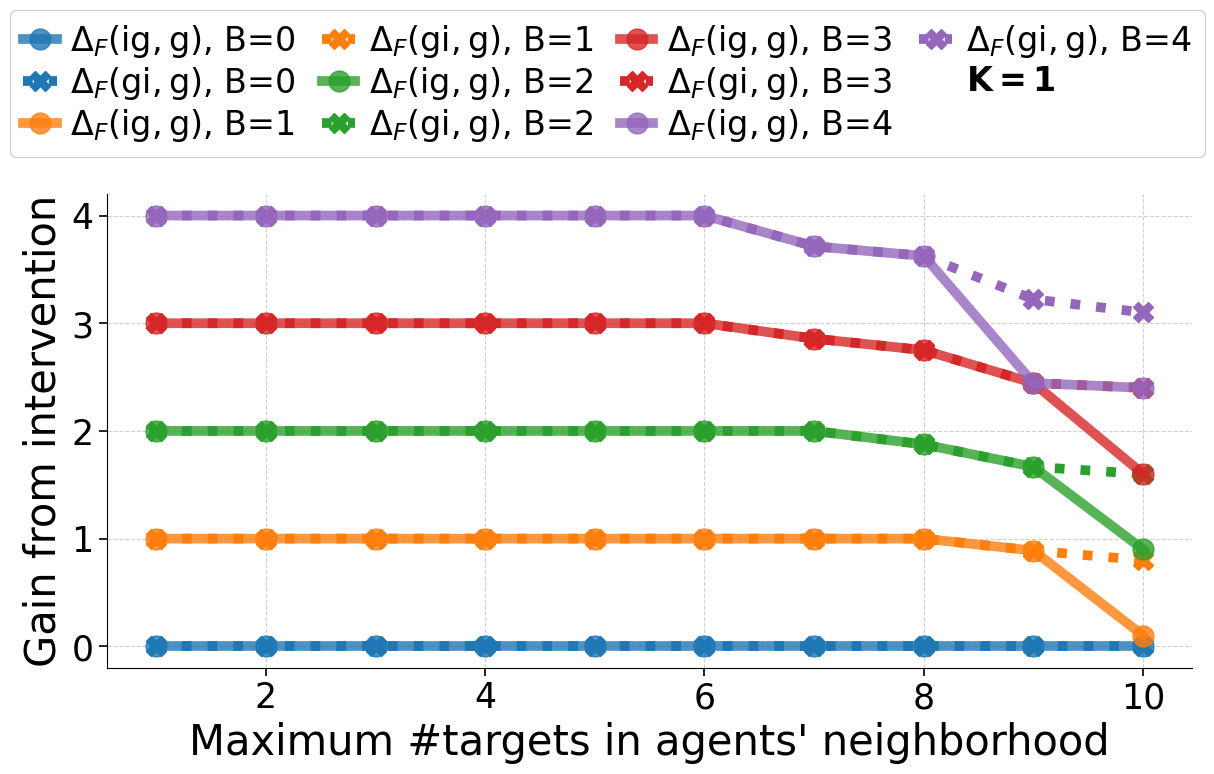

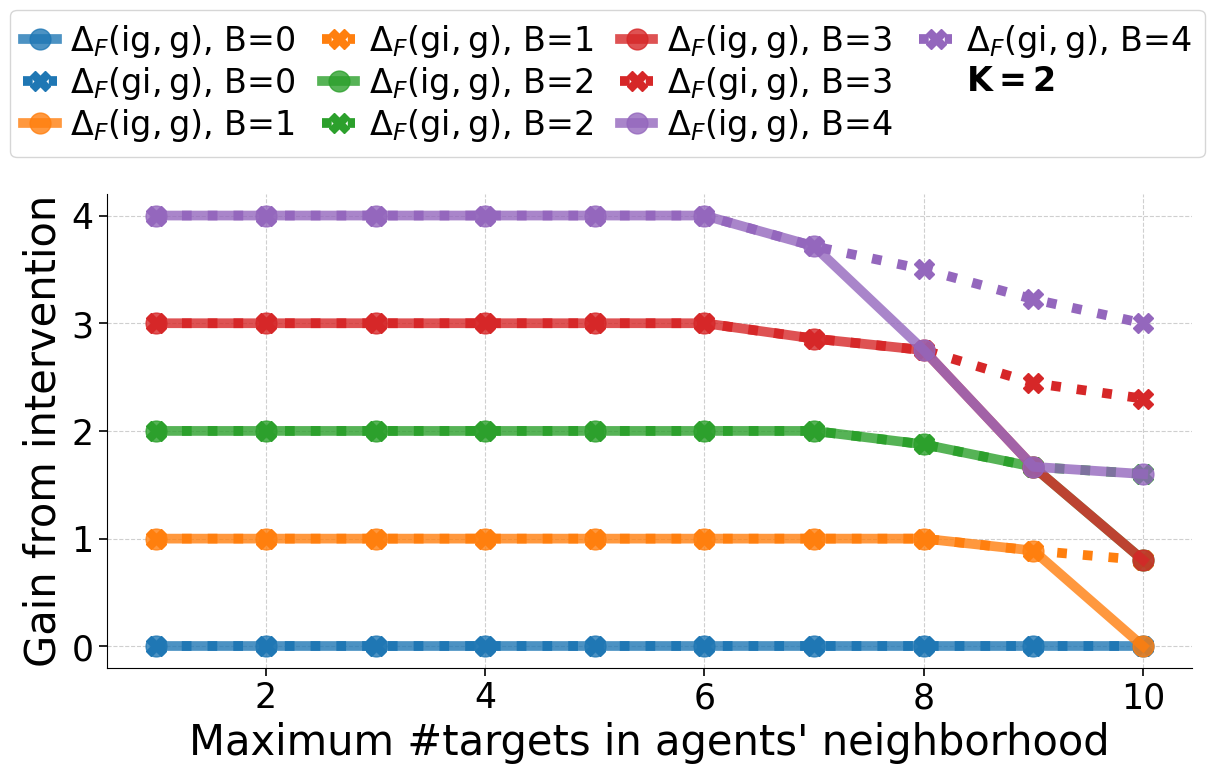

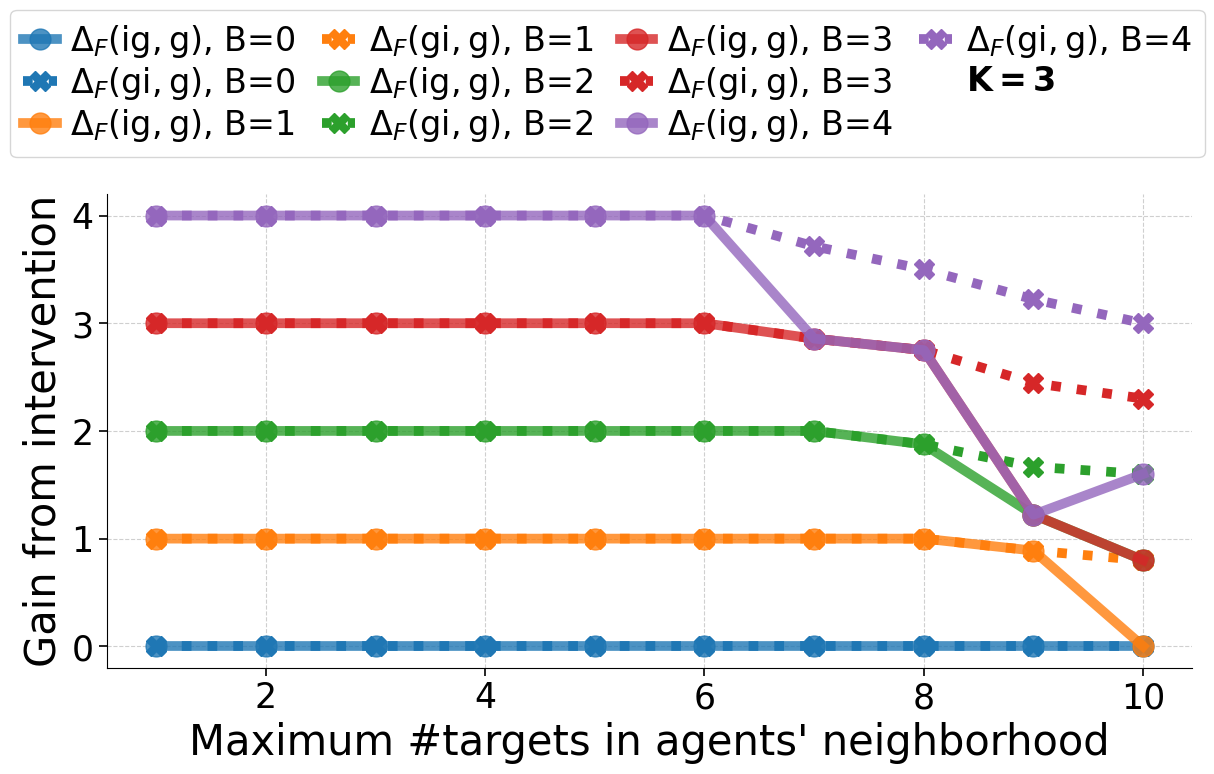

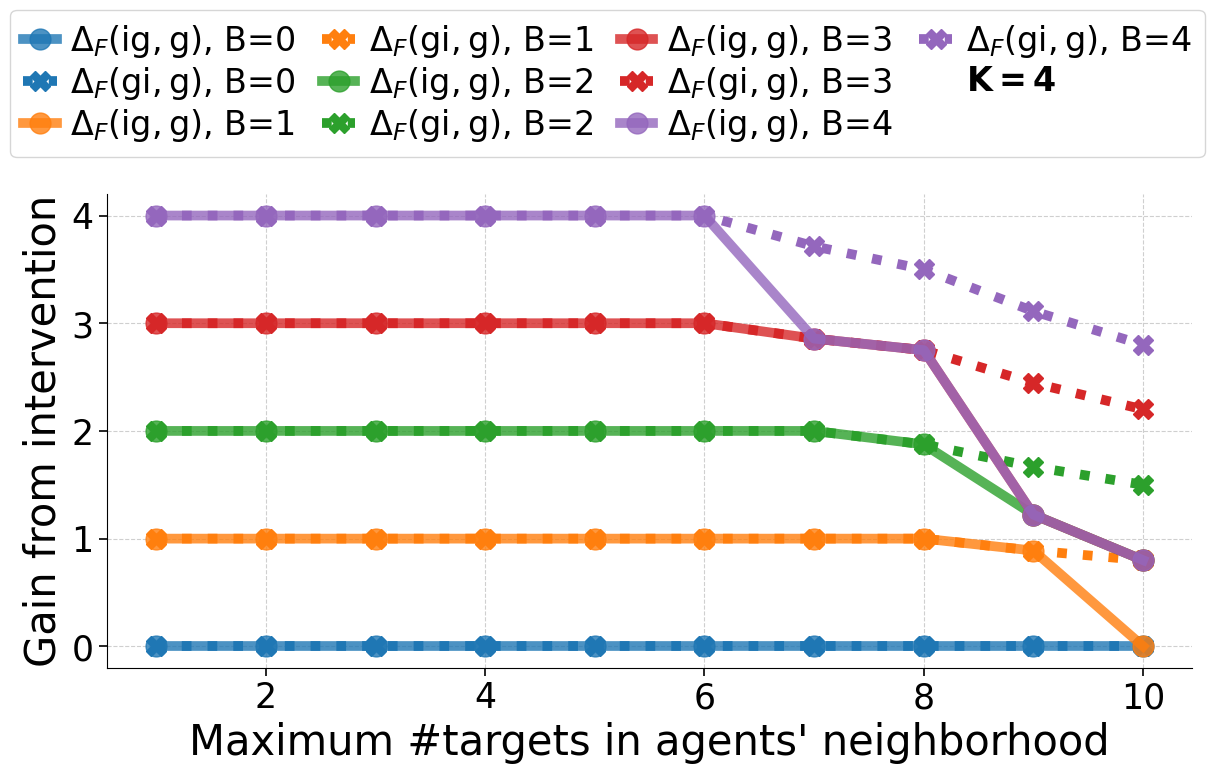

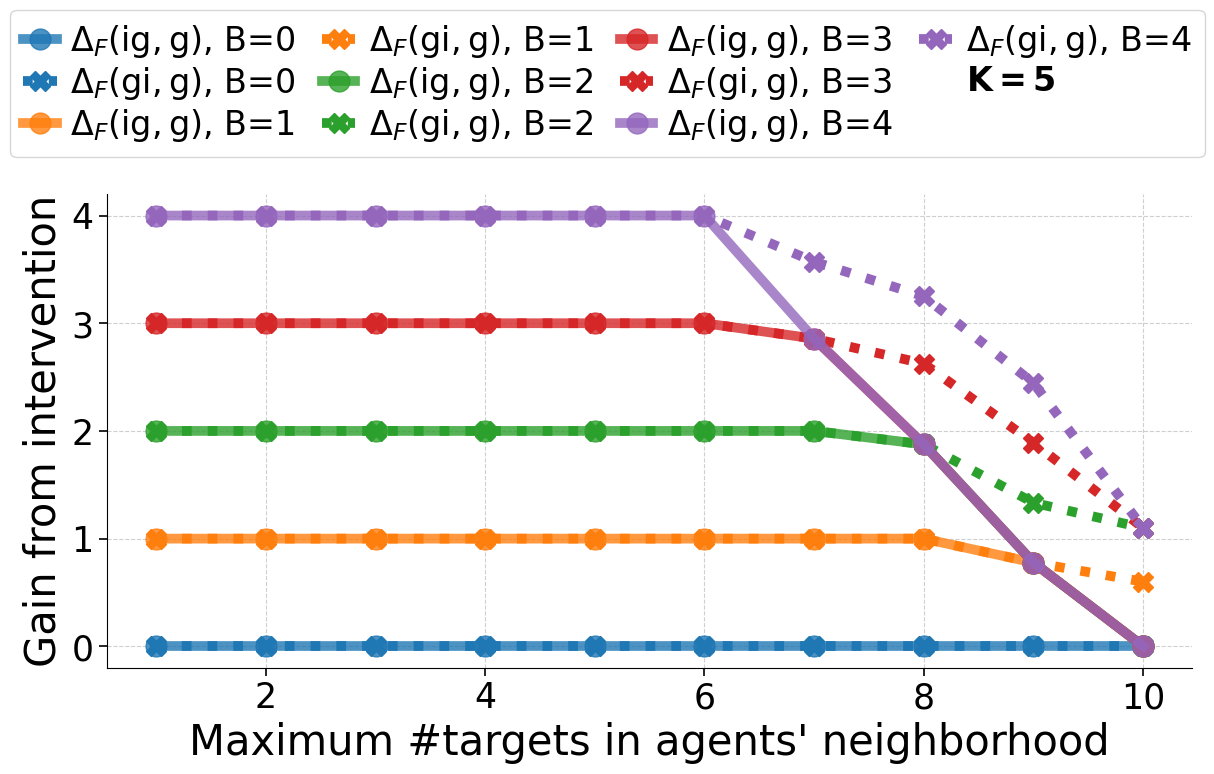

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                                      thresh=False,
                                      save_as = "./im_results/figures/"+name+"_imb4aftersm_results_knn")